In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import dill
import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = True
%load_ext autoreload
%autoreload 2
import pathlib
import numpy as np
import getdist
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import MixtureND
%matplotlib inline






In [2]:
import pickle as pk
import dill as dill
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os

import getdist
from getdist import plots, MCSamples




def get_MC_samps_FoM(fname, param_acorr='sigma8', acorr_min=0.035, acorr_max = 0.05, nchains = 96, ind_frac_rm = 0.1, names=None, labels=None):
    df = pk.load(open(fname,'rb'))
    sig8 = df[param_acorr]
    
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance
    
    acorr = autocorrelation(sig8_rs, axis=1)
    ind_del = []
    for ji in range(acorr.shape[0]):
        if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
            ind_del.append(ji)    
    
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    if names is None:
        names = keys
        indsel_names = np.arange(len(names))
    else:
        indsel_names = []
        for name in names:
            indsel_names.append(keys.index(name))
    
    
    save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
    labels_all = {'A_IA':r'$A_{\rm IA}$',
     'Ob0':r'$\Omega_b$',
     'Om0':r'$\Omega_{\rm m}$',
     'eta_IA':r'$\eta_{\rm IA}$',
     'log10_Mc0':r'$\log(M_c)$',
     'theta_co_0':r'$\theta_{\rm co, 0}$',
     'gamma_rhogas':r'$\gamma$',
     'nu_z':r'$\nu_z$',
     'h':r'$h$',
     'ns':r'$n_s$',
     'mu_beta':r'$\mu_{\beta}$',
     'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
     'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
     'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
     'log10_Mc0':r'$\log(M_c)$',
        'delta_rhogas':r'$\delta$',
        'gamma_rhogas':r'$\gamma$',
     'sigma8':r'$\sigma_8$',
     'theta_ej_0':r'$\theta_{\rm ej, 0}$',
     'S8':r'$S_8$',
     'alpha_nt':r'$\alpha_{\rm nt}$',
     'alpha_ky':r'$\alpha_{\rm ky}$',
     'alpha_kk':r'$\alpha_{\rm kk}$',
    'Delta_z_bias_array_0':r'$\Delta z_1$',
     'Delta_z_bias_array_1':r'$\Delta z_2$',
     'Delta_z_bias_array_2':r'$\Delta z_3$',
     'Delta_z_bias_array_3':r'$\Delta z_4$',
     'mult_shear_bias_array_0':r'$m_1$',
     'mult_shear_bias_array_1':r'$m_2$',
     'mult_shear_bias_array_2':r'$m_3$',
     'mult_shear_bias_array_3':r'$m_4$',
    'alphasat_Nsat':r'$\alpha_{\rm sat}$',
    'beta_a_fshmr':r'$\beta^{\rm galaxy}_{\rm z}$',
    'beta_fshmr':r'$\beta^{\rm galaxy}_{\rm 0}$',
    'delta_a_fshmr':r'$\delta^{\rm galaxy}_{\rm z}$',
    'delta_fshmr':r'$\delta^{\rm galaxy}_{\rm 0}$',
    'log10M1_a_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm z}$',
    'log10M1_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm 0}$',
    'siglogMstar_Ncen':r'$\sigma_{\log M^{\rm galaxy}_{\star}}$',
    }
    
    if labels is None:
        labels = []
        
        for key in keys:
            if key in labels_all.keys():
                labels.append(labels_all[key])
            else:
                labels.append(r'm')
    
    
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    # print(samps.shape, samps_sel.shape)
    from numpyro.diagnostics import gelman_rubin, effective_sample_size, print_summary
    ind_gr = ind_sigma8
    gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
    # print(gr)
    
    samples = MCSamples(samples=samps[:,indsel_names],names = names, labels = labels)
    # marge = samples.getMargeStats()
    pars_all = samples.getParamNames().getRunningNames()
    om_index = pars_all.index('Om0')
    sig8_index = pars_all.index('sigma8')
    FoM_Om_sig8 = 1/np.sqrt(np.linalg.det(samples.getCov(pars=[om_index,sig8_index])))

    return samples, FoM_Om_sig8




In [3]:
# ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr_v2/'
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_july_v5/'
probe = 'ky_kk_gg_gy_gk_ge'
lmax_array = [1000,2000,4000,8000]
FoM_all_probes_all = []
for lmax in lmax_array:
    # samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')    
    samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_6000_warmup_6000_num_chains_96_treedepth_4.pkl')        
    print(lmax, FoM_lmax)
    FoM_all_probes_all.append(FoM_lmax)



Removed no burn in
1000 42386.58506609326
Removed no burn in
2000 61621.65404857672
Removed no burn in
4000 83824.51421144043
Removed no burn in
8000 74958.29691410514


In [9]:
# ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/'

acorr_min = 0.05
acorr_max = 0.075

probe = 'kk_gg_gk_ge'
lmax_array = [1000,2000,4000,8000]
FoM_all_notSZ = []
for lmax in lmax_array:
    # samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')    
    if lmax == 8000:
        samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_6000_warmup_6000_num_chains_96_treedepth_4.pkl', acorr_min=acorr_min, acorr_max = acorr_max)        
    else:
        samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl')        
    print(lmax, FoM_lmax)
    FoM_all_notSZ.append(FoM_lmax)



Removed no burn in
1000 29157.895507516776
Removed no burn in
2000 37044.41289553343
Removed no burn in
4000 45074.15473295138
Removed no burn in
8000 46579.43751334468


In [25]:
# ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/'


# acorr_min = 0.05
# acorr_max = 0.075
acorr_min = 0.06
acorr_max = 0.1

probe = 'kk_gg_gk'
lmax_array = [1000,2000,4000,8000]
FoM_all_notSZ_nokSZ = []
for lmax in lmax_array:
    # samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')    
    if lmax < 8000:
        samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl', acorr_min=acorr_min, acorr_max = acorr_max)        
    else:
        samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl')        
    print(lmax, FoM_lmax)
    FoM_all_notSZ_nokSZ.append(FoM_lmax)



Removed no burn in
1000 18252.965175140067
Removed no burn in
2000 22099.151982345113
Removed no burn in
4000 31323.8208541883
Removed no burn in
8000 38171.2137194219


In [26]:
acorr_min = 0.06
acorr_max = 0.1
# ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/'
probe = 'gg_gk_ge'
lmax_array = [1000,2000,4000,8000]
FoM_all_noshear = []
for lmax in lmax_array:
    # samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')    
    # samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl', acorr_min=acorr_min, acorr_max = acorr_max)        
    if lmax > 1000:
        samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_6000_warmup_6000_num_chains_96_treedepth_4.pkl', acorr_min=acorr_min, acorr_max = acorr_max)        
    else:
        samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl', acorr_min=acorr_min, acorr_max = acorr_max)        
    print(lmax, FoM_lmax)
    FoM_all_noshear.append(FoM_lmax)



Removed no burn in
1000 14902.615281256261
Removed no burn in
2000 17670.42696106133
Removed no burn in
4000 19278.10283874526
Removed no burn in
8000 22977.083256517886


In [27]:
# acorr_min = 0.035
# acorr_max = 0.07
# ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/'

acorr_min = 0.06
acorr_max = 0.1

probe = 'gg_gk'
lmax_array = [1000,2000,4000,8000]
FoM_all_noshear_nokSZ = []
for lmax in lmax_array:
    # samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl', acorr_min=acorr_min, acorr_max = acorr_max)  
    samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl', acorr_min=acorr_min, acorr_max = acorr_max)  
    print(lmax, FoM_lmax)
    FoM_all_noshear_nokSZ.append(FoM_lmax)



Removed no burn in
1000 9974.565740889415
Removed no burn in
2000 10376.291013014139
Removed no burn in
4000 15035.018343027512
Removed no burn in
8000 18201.30339129872


In [29]:
# acorr_min = 0.035
# acorr_max = 0.07
# ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr/'

acorr_min = 0.06
acorr_max = 0.1

probe = 'gg_gk'
lmax_array = [1000,2000,4000,8000]
FoM_all_noshear_nokSZ_wbao = []
for lmax in lmax_array:
    # samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl', acorr_min=acorr_min, acorr_max = acorr_max)  
    samps, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4_wbaoprior_True.pkl', acorr_min=acorr_min, acorr_max = acorr_max)  
    print(lmax, FoM_lmax)
    FoM_all_noshear_nokSZ_wbao.append(FoM_lmax)



Removed no burn in
1000 41021.54035982188
Removed no burn in
2000 51696.15976106633
Removed no burn in
4000 54352.53259376867
Removed no burn in
8000 54895.25069705673


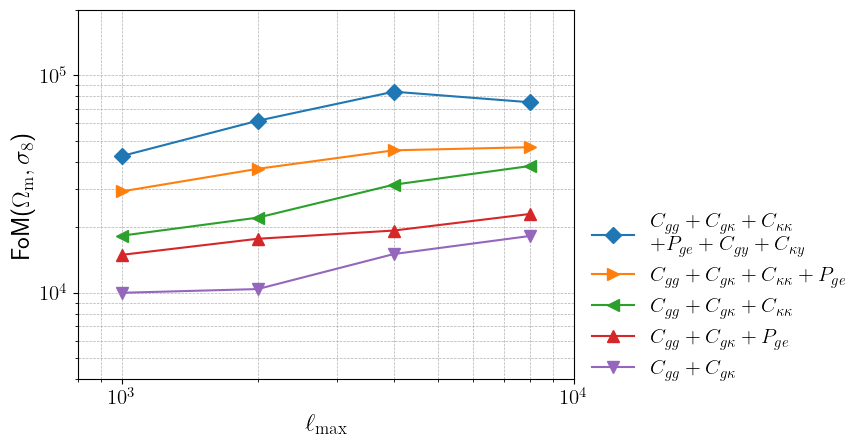

In [28]:
pl.figure()

pl.plot(lmax_array, FoM_all_probes_all, 'D-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + C_{\kappa \kappa}$' +  '\n' + r'$+ P_{ge} + C_{gy} + C_{\kappa y}$')
pl.plot(lmax_array, FoM_all_notSZ, '>-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + C_{\kappa \kappa} + P_{ge}$')
pl.plot(lmax_array, FoM_all_notSZ_nokSZ, '<-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + C_{\kappa \kappa}$')
pl.plot(lmax_array, FoM_all_noshear, '^-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + P_{ge}$')
pl.plot(lmax_array, FoM_all_noshear_nokSZ, 'v-', ms=8.0, label=r'$C_{gg} + C_{g \kappa}$')


pl.xscale('log')
pl.yscale('log')
pl.legend(frameon=False, fontsize=15, bbox_to_anchor=(1, 0.5))
pl.ylim(4e3, 2e5)
pl.xlim(800, 1e4)
pl.tick_params(axis='both', which='major', labelsize=15)
pl.tick_params(axis='both', which='minor', labelsize=15)
pl.xlabel(r'$\ell_{\rm max}$', fontsize=18)
pl.grid(which='both', linestyle='--', linewidth=0.5)
pl.ylabel(r'FoM($\Omega_{\rm m}, \sigma_8$)', fontsize=18)
sdir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/'
# pl.savefig(sdir + 'FoM_vs_ellmax_v1.pdf', bbox_inches='tight')




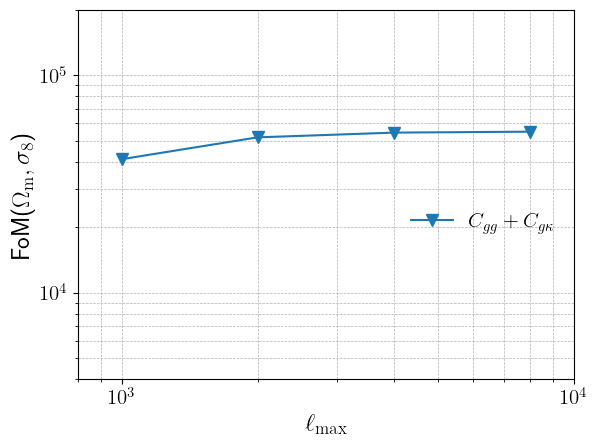

In [34]:
pl.figure()

# pl.plot(lmax_array, FoM_all_probes_all, 'D-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + C_{\kappa \kappa}$' +  '\n' + r'$+ P_{ge} + C_{gy} + C_{\kappa y}$')
# pl.plot(lmax_array, FoM_all_notSZ, '>-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + C_{\kappa \kappa} + P_{ge}$')
# pl.plot(lmax_array, FoM_all_notSZ_nokSZ, '<-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + C_{\kappa \kappa}$')
# pl.plot(lmax_array, FoM_all_noshear, '^-',  ms=8.0,label=r'$C_{gg} + C_{g \kappa} + P_{ge}$')
pl.plot(lmax_array, FoM_all_noshear_nokSZ_wbao, 'v-', ms=8.0, label=r'$C_{gg} + C_{g \kappa}$')


pl.xscale('log')
pl.yscale('log')
pl.legend(frameon=False, fontsize=15, bbox_to_anchor=(1, 0.5))
pl.ylim(4e3, 2e5)
pl.xlim(800, 1e4)
pl.tick_params(axis='both', which='major', labelsize=15)
pl.tick_params(axis='both', which='minor', labelsize=15)
pl.xlabel(r'$\ell_{\rm max}$', fontsize=18)
pl.grid(which='both', linestyle='--', linewidth=0.5)
pl.ylabel(r'FoM($\Omega_{\rm m}, \sigma_8$)', fontsize=18)
sdir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/'
# pl.savefig(sdir + 'FoM_vs_ellmax_v1.pdf', bbox_inches='tight')




Removed no burn in
Removed no burn in


<Figure size 900x900 with 0 Axes>

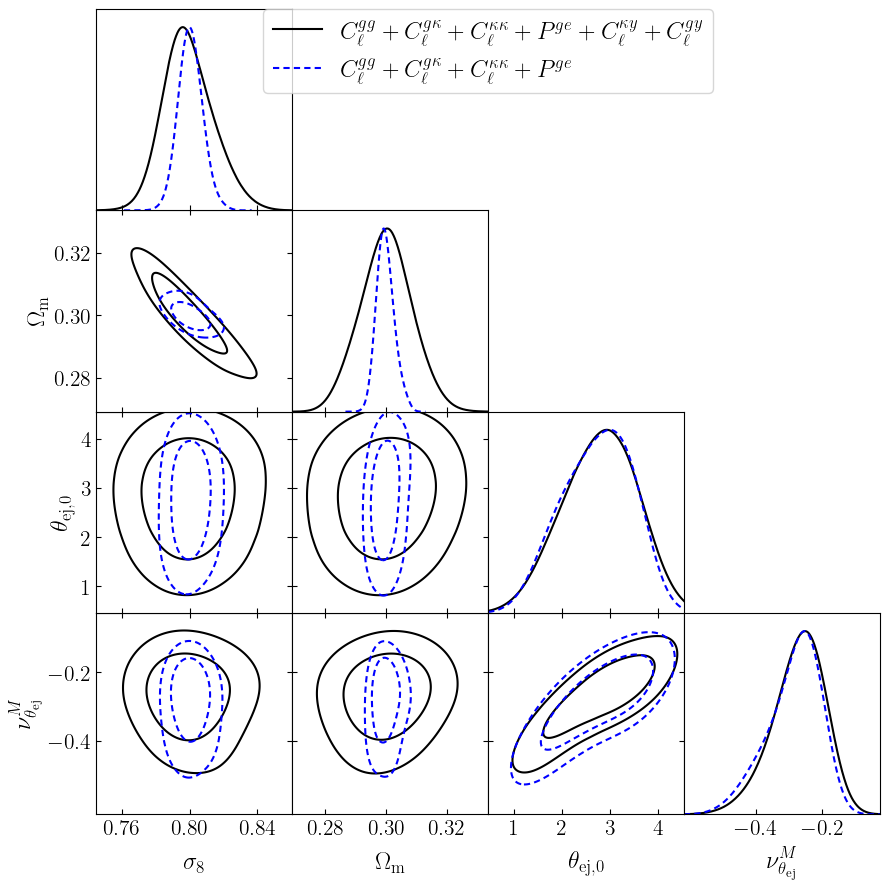

In [33]:
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M',  'nu_theta_ej_z',  'mu_beta','A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8']
# params = ['Om0','A_IA', 'eta_IA', 'sigma8',  'S8', 'h', 'ns', 'Ob0','mult_shear_bias_array_3',  'Delta_z_bias_array_3']
g = plots.getSinglePlotter(width_inch=9.0, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}

acorr_min = 0.06
acorr_max = 0.1

probe = 'gg_gk'
lmax = 8000
# samps_8000, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl')        
samps_8000, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl', acorr_min=acorr_min, acorr_max = acorr_max)        

# lmax = 1000
samps_4000, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4_wbaoprior_True.pkl', acorr_min=acorr_min, acorr_max = acorr_max)        
# samps_4000, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_6000_warmup_6000_num_chains_96_treedepth_4.pkl', ind_frac_rm = 0.5)        


params = samps_8000.getParamNames().getRunningNames()
# g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samps_8000, samps_4000], ['sigma8', 'Om0', 'theta_ej_0', 'nu_theta_ej_M'], line_args=line_args, 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''], legend_labels = [r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell} + P^{ge} + C^{\kappa y}_{\ell} + C^{gy}_{\ell}$',
                                                        r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell} + P^{ge}$',
                                                        r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell}$'])
# save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# g.export(save_plot_dir  + 'contour_Om0_S8_nuejM_internal.pdf')
import matplotlib
%matplotlib inline
pl.show()





In [5]:
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr_v2/'
lmax = 4000

probe = 'ky_kk_gg_gy_gk_ge'
chain_all, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')    

probe = 'kk_gg_gk_ge'
chain_wkSZ, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')    

probe = 'kk_gg_gk'
chain_nokSZ, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')    



Removed no burn in
Removed no burn in
Removed no burn in


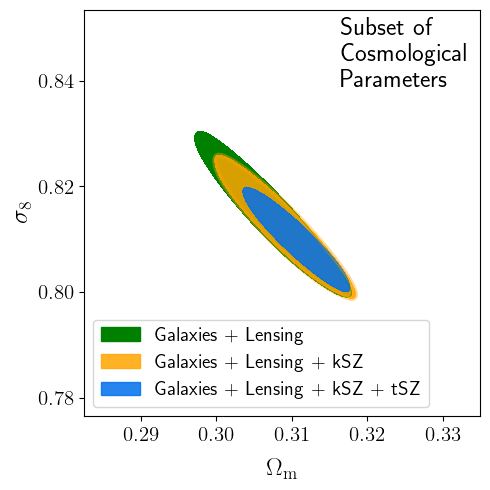

In [21]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_nokSZ, chain_wkSZ, chain_all]
g.plot_2d(all_samples,'Om0', 'sigma8', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] )
        #   ,lims=[0.284, 0.346, 0.77, 0.9])  
g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ', r'Galaxies + Lensing + kSZ + tSZ'], legend_loc='lower left', fontsize=14)
g.add_text('Subset of' + '\n' + 'Cosmological' + '\n' + 'Parameters', x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
sdir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/'
g.export(fname = sdir+'cosmo_directcal.pdf')
# g.export(fname = '/mnt/home/spandey/ceph/GODMAX/notebooks/plots/Om_sig8_forecast_all_FINALSET.pdf')



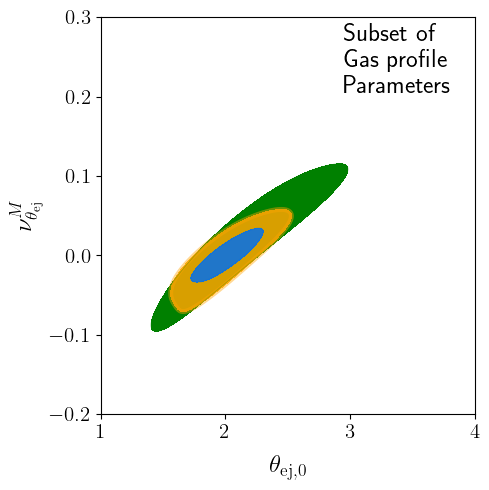

In [22]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_nokSZ, chain_wkSZ, chain_all]
g.plot_2d(all_samples,'theta_ej_0', 'nu_theta_ej_M', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] 
        #    ,lims=[-18, 22, -1.5, 2])  
           ,lims=[1, 4, -0.2, 0.3])             
# g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ'], legend_loc='lower left', fontsize=14)
g.add_text('Subset of' + '\n' + 'Gas profile   ' + '\n' + 'Parameters',  x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
g.export(fname = sdir+'gas_prof_directcal.pdf')



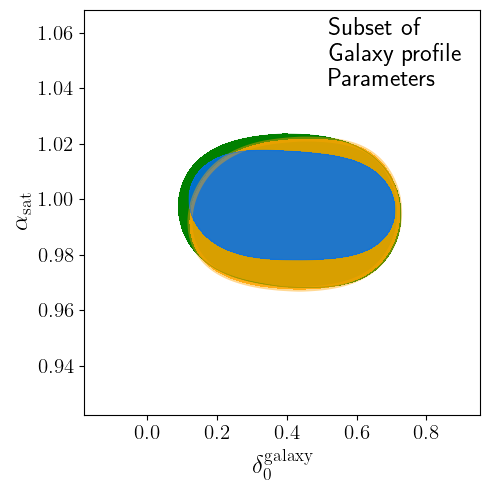

In [24]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_nokSZ, chain_wkSZ, chain_all]
# g.plot_2d(all_samples,'beta_fshmr', 'alphasat_Nsat', 
g.plot_2d(all_samples,'delta_fshmr', 'alphasat_Nsat', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] )  
g.add_text('Subset of' + '\n' 'Galaxy profile   ' + '\n' + 'Parameters',  x=0.62, y=0.89, fontsize=18, horizontalalignment='left')        
# g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ'], legend_loc='lower left', fontsize=14)
g.export(fname = sdir+'gal_prof_directcal.pdf')


